# Which early network signals of new topics travel? RQ1 held-out portability demo

This notebook is a runnable walkthrough of the **RQ1 held-out deliverable**. The experiment asks which *early* signals of
a newly emerging scientific concept (OpenAlex concepts, measured over the first three years `t0..t0+2`) predict how the
concept later spreads, **beyond a 5-variable size/diffusion baseline (B5)**, and whether those signals *travel* from the
development domains (CS / Engineering / BGM / Medicine) to held-out domains (Physics, Life & Environment, Social
sciences, Math & Decision sciences).

**What the full artifact does** (`method.py`, an idempotent orchestrator of 9 steps):

1. Two zero-credit passes over the OpenAlex S3 snapshot (Pass A: grounded concept matches; Pass B: windowed citations).
2. 53 indicators in 7 families (popularity **E**, disciplinary **F**, landing **G**, retained-frontier **FR**,
   co-occurrence ego-network **A**, co-author **S**) plus the **B5** baseline (`logvol, growth_c, offhome_share, entropy, reach`).
3. Outcomes: O1c/O1b uptake, O2r_m50/O2r_resid breadth, O3 transience, O4 citation growth, O5/O5_WW external recognition.
4. **DEV-only ranking**: partial Spearman `psp(x, y | B5 + group + t0)` with concept bootstraps, frozen top-10 per outcome.
5. **Single unseal**: frozen indicators scored once on the held-out units, DerSimonian-Laird pooling, Holm correction.

The OpenAlex passes need a ~100 GB snapshot and hours of compute, so they cannot run here. This demo keeps the original
orchestrator code (as a dry run), then runs the **core statistics of steps 5 and 6 with the original code** on the
per-concept indicator/outcome table that the pipeline produced (`method_out.json`):

* **"DEV"** = 50 cohort concepts (onset 2010-14) whose home field is a DEV domain (`COH_DEVHOME`),
* **"held-out"** = 50 cohort concepts whose home field is a held-out domain (`COH_OTHER`).

Headline result of the full run: breadth (O2r_m50 / O2r_resid) is predictable beyond B5 and portable
(e.g. `M0_density_end` pooled psp +0.377 [0.280, 0.466]); uptake, citation growth and recognition largely are not.
With only 100 concepts the demo's confidence intervals are wide. It shows the procedure; it is not a replication.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# The demo only needs core scientific packages, all pre-installed on Colab.
# (The full pipeline also uses loguru, igraph, leidenalg, interpret(EBM), joblib; they are not needed for this demo.)
# numpy, pandas, scipy, matplotlib: pre-installed on Colab, install locally only at Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original method.py import block ---
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from pathlib import Path

# --- imports used by lib/rq1stats.py, dev_select.py, heldout.py ---
import json
import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata, spearmanr

# --- added for the notebook's result plots ---
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_ud-q6jnkjLXa/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["method_name"])
print(data["metadata"]["demo_subset"])
print("examples:", len(data["datasets"][0]["examples"]))

RQ1 held-out indicator portability (DEV freeze -> sealed held-out scoring)
100 cohort concepts (t0 2010-14) with all 4 continuous outcomes observed: 50 COH_DEVHOME (home CS/Eng/BGM/Med) + 50 COH_OTHER (home PHYS/LIFEENV/SOC/MATHDEC), stratified by home group, seed 20260928
examples: 100


## Configuration

All tunable parameters in one place. The bootstrap counts are the main cost driver. The original values
(`N_BOOT_CONT = 1000` in `dev_select.py`, `B_HELD = 1000` in `heldout.py`) are noted next to each one. The frozen
selection rule (`MAX_MISSING`, `DEDUP_RHO`, top-10) is the same as in the original.

In [5]:
N_BOOT_CONT = 200      # DEV ranking bootstrap resamples per (indicator, outcome); original: 1000
B_HELD = 200           # held-out scoring bootstrap resamples; original: 1000
MAX_MISSING = 0.30       # an indicator with > 30% missing values in DEV is never frozen (original)
DEDUP_RHO = 0.85         # greedy de-duplication of near-identical indicators, |Spearman| > 0.85 (original)
TOP_K = 10               # frozen top-k per outcome (original: 10)
SEED = 20260928          # lib/common.py SEED
DEV_UNIT = "COH_DEVHOME" # demo "DEV" unit: cohort concepts whose home field is CS/Eng/BGM/Med
HELD_UNIT = "COH_OTHER"  # demo held-out unit: cohort concepts whose home field is PHYS/LIFEENV/SOC/MATHDEC

## 1. The original orchestrator (`method.py`), dry run

This is the original `method.py` code. `STEPS` lists each pipeline stage, the commands it runs, and the *marker*
file whose existence makes the stage skip. Two small notebook adaptations: `main()` takes an `argv` list instead
of reading the command line, and a `dry_run` flag prints what would run instead of launching the scripts (the
OpenAlex S3 passes are not runnable in Colab). `lib/common.py` provides `DATA/LOGS/RES` and a loguru logger;
here they are replaced by plain paths and a print-based logger.

In [6]:
ROOT = Path.cwd()
# lib/common.py: pipeline folders
DATA, LOGS, RES = ROOT / "data", ROOT / "logs", ROOT / "results"


def setup_logger(name: str):
    # stand-in for lib/common.setup_logger (loguru, format "{time:HH:mm:ss}|{level:<7}|{message}")
    class _L:
        def info(self, m): print(f"{time.strftime('%H:%M:%S')}|INFO   |{m}")
        def warning(self, m): print(f"{time.strftime('%H:%M:%S')}|WARNING|{m}")
    return _L()


PY = sys.executable
STEPS = [
    ("tests", [["tests/test_units.py"], ["tests/t0_8_ego_port.py"]], RES / "t0_8_ego_port.json"),
    ("passA", [["passA.py", "--workers", "{w}"], ["passA.py", "--merge"]], DATA / "passA_info.json"),
    ("passB", [["passB.py", "--workers", "{w}"], ["passB.py", "--merge"]], DATA / "passB_info.json"),
    ("features", [["build_features.py", "--stage", "all", "--workers", "{w}"]], RES / "indicator_matrix.parquet"),
    ("outcomes", [["outcomes.py"]], DATA / "outcomes_sealed.parquet"),
    ("dev_select", [["dev_select.py", "--stage", "all", "--workers", "{w}"]], LOGS / "seal.log"),
    ("heldout", [["heldout.py", "--stage", "all", "--workers", "{w}"]], RES / "sensitivities_pooled.json"),
    ("audit", [["audit.py"]], RES / "audit.json"),
    ("outputs", [["make_outputs.py"]], RES / "rq1_heldout.json"),
]


def main(argv: list[str] | None = None, dry_run: bool = True) -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default=None)
    ap.add_argument("--only", default=None)
    ap.add_argument("--workers", type=int, default=5)
    a = ap.parse_args(argv)
    logger = setup_logger("method")
    names = [s[0] for s in STEPS]
    i0 = names.index(a.start) if a.start else 0
    for name, cmds, marker in STEPS[i0:]:
        if a.only and name != a.only:
            continue
        if marker.exists() and not (a.only or a.start == name):
            logger.info(f"skip {name}: {marker.relative_to(ROOT)} exists")
            continue
        for c in cmds:
            cmd = [PY] + [x.format(w=a.workers) for x in c]
            if dry_run:  # notebook: show the plan instead of launching the OpenAlex pipeline
                logger.info(f"[dry-run] {name}: would run {' '.join(c)}  (skip marker: {marker.relative_to(ROOT)})")
                continue
            t = time.time()
            logger.info(f"run {' '.join(c)}")
            r = subprocess.run(cmd, cwd=ROOT)
            if r.returncode != 0:
                raise SystemExit(f"step {name} failed ({' '.join(c)}), exit {r.returncode}")
            logger.info(f"done {' '.join(c)} in {(time.time()-t)/60:.1f} min")


main([], dry_run=True)

02:10:48|INFO   |[dry-run] tests: would run tests/test_units.py  (skip marker: results/t0_8_ego_port.json)
02:10:48|INFO   |[dry-run] tests: would run tests/t0_8_ego_port.py  (skip marker: results/t0_8_ego_port.json)
02:10:48|INFO   |[dry-run] passA: would run passA.py --workers {w}  (skip marker: data/passA_info.json)
02:10:48|INFO   |[dry-run] passA: would run passA.py --merge  (skip marker: data/passA_info.json)
02:10:48|INFO   |[dry-run] passB: would run passB.py --workers {w}  (skip marker: data/passB_info.json)
02:10:48|INFO   |[dry-run] passB: would run passB.py --merge  (skip marker: data/passB_info.json)
02:10:48|INFO   |[dry-run] features: would run build_features.py --stage all --workers {w}  (skip marker: results/indicator_matrix.parquet)
02:10:48|INFO   |[dry-run] outcomes: would run outcomes.py  (skip marker: data/outcomes_sealed.parquet)
02:10:48|INFO   |[dry-run] dev_select: would run dev_select.py --stage all --workers {w}  (skip marker: logs/seal.log)
02:10:48|INFO   

## 2. Indicator dictionary (`lib/indicators.py`)

The 53 candidate indicators grouped by family, each with its formula, plus the B5 baseline and the outcome lists.
This is the original module, copied as-is. The `A` family is the co-occurrence ego network ported from EXP3.

In [7]:
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]

FAMILIES: dict[str, list[tuple[str, str]]] = {
    "E": [("share", "grounded works t0..t0+2 per million base works (EXP5)"),
          ("growth_ind", "log((N_t0+2 + 1)/(N_t0+1 + 1)) (EXP5)"),
          ("accel", "quadratic coefficient of log1p(N) over t0..t0+2 (EXP5)"),
          ("burst", "Kleinberg 2-state burst weight t0-3..t0+2 (EXP5)"),
          ("author_growth", "log1p(distinct authors t0+2) - log1p(distinct authors t0) (Pass A)"),
          ("n_authors_early", "log1p(distinct authors t0..t0+2) (Pass A)")],
    "F": [("log_offhome_volume", "log1p(off-home venue-labelled works t0..t0+2) (EXP5)"),
          ("rao_stirling", "sum_ij p_i p_j (1 - phi_ij/max phi), venue-field shares t0..t0+2, EXP6 1998-2002 PMI phi"),
          ("fields_gained_per_yr", "(|ENTERED(t0+2)| - |ENTERED(t0)|)/2, off-home, counts restricted to t0..t0+2")],
    "G": [("G", "gateway(eig)-weighted off-home landing (EXP5; previously scored on held-out)"),
          ("G_A", "G over t0..t0+1 (EXP5; previously scored)"),
          ("G_btw", "betweenness-gateway landing (EXP5; previously scored)"),
          ("G_deg", "degree-gateway landing (EXP5)"),
          ("G_phimin", "phi_min-gateway landing (EXP5)"),
          ("REL_home", "mean phi(home, landing field) of off-home works (EXP5)"),
          ("RS", "Rao-Stirling with 1 - phi_min distances (art_33 / EXP5)")],
    "FR": [("CONTACT_REACH", "# off-home fields with >= 1 labelled work t0..t0+2"),
           ("RETAINED_REACH", "# off-home fields with >= 2 works in >= 2 of the 3 years"),
           ("RETENTION_RATIO_early", "RETAINED_REACH / max(CONTACT_REACH, 1)"),
           ("FRONTIER_POTENTIAL", "sum_{k not entered, off-home} mean_{j retained} phi[j,k]"),
           ("D_rca_end", "# off-home fields entered by the RCA rule by t0+2 (EXP6 h2.rca_entered)"),
           ("D_vol_end", "# off-home fields with cumulative >= 2 works by t0+2 (EXP6 h2.states)"),
           ("M0_density_end", "mean Hidalgo density phi[E].sum/colsum over not-entered off-home fields at t0+2")],
    "A": [("D_z", "z of # backbone communities reached by NEW neighbours vs frequency-matched null (200 draws)"),
          ("D_ratio", "observed / null-mean # communities of NEW neighbours"),
          ("D_rare", "rarefied (r=10) # communities of NEW neighbours"),
          ("D_sub", "z of # subfields reached by NEW neighbours"),
          ("D_obs", "# distinct communities of NEW neighbours"),
          ("NOV", "share of NEW neighbours outside the W1 dominant community"),
          ("NOV_res", "NOV minus its degree-preserving expectation"),
          ("F_res", "growth of mean top-20 neighbour PMI W1->W3 minus multinomial-null mean"),
          ("F_z", "F_res / null SD"),
          ("deg_W1", "# PMI>0 neighbours (n>=2) in W1 = t0"),
          ("deg_W3", "# PMI>0 neighbours in W3 = t0+2"),
          ("deg_growth", "log(deg_W3+1) - log(deg_W1+1)"),
          ("str_growth", "log(sum PMI W3 + 1) - log(sum PMI W1 + 1)"),
          ("new_edge_rate", "(M/3) / (deg_W1 + 1)"),
          ("edge_persistence", "mean Jaccard of neighbour sets W1-W2, W2-W3"),
          ("turnover", "share of W1 neighbours absent in W3"),
          ("participation", "1 - sum of squared community shares of W3 neighbours"),
          ("n_comm_W3", "# communities among W3 neighbours"),
          ("comm_entropy", "Shannon entropy of W3 neighbour community weights"),
          ("comm_transitions", "# changes of dominant community W1->W2->W3"),
          ("ego_density_W3", "backbone edge density among W3 neighbours"),
          ("ego_density_change", "ego density W3 - W1"),
          ("btw_end", "betweenness (cutoff 3) of the concept inserted in the kNN backbone at t0+2"),
          ("btw_change", "btw_end - btw at t0"),
          ("kcore_end", "k-core number of the inserted concept at t0+2"),
          ("constraint_end", "Burt constraint of the inserted concept at t0+2"),
          ("constraint_change", "constraint t0+2 - t0")],
    "S": [("S_comp", "# co-author components / # off-home early works (with author ids)"),
          ("S_comp_n", "# co-author components / # distinct off-home authors"),
          ("S_isolated_share", "share of off-home early works sharing no author with another off-home work")],
}

INDICATORS = [n for fam in FAMILIES.values() for n, _ in fam]
FAMILY_OF = {n: f for f, lst in FAMILIES.items() for n, _ in lst}
FORMULA_OF = {n: t for lst in FAMILIES.values() for n, t in lst}
PREVIOUSLY_SCORED = {"G", "G_A", "G_btw"}

CONT_OUTCOMES = ["O1c", "O2r_m50", "O2r_resid", "O4"]
BIN_OUTCOMES = ["O1b", "O3", "O5", "O5_WW"]
OUTCOMES = CONT_OUTCOMES + BIN_OUTCOMES
T0_BASELINE_OUTCOMES = {"O5", "O5_WW"}      # B5 + onset-year dummies (Wikipedia creation wave)

print(len(INDICATORS), "indicators;", {f: len(v) for f, v in FAMILIES.items()})

53 indicators; {'E': 6, 'F': 3, 'G': 7, 'FR': 7, 'A': 27, 'S': 3}


## 3. Statistics (`lib/rq1stats.py`)

These are the original functions, copied as-is (the logistic / dAUC helpers used only for the binary outcomes are
left out).

* `psp_point`: **partial Spearman** = Pearson correlation of the residuals of `rank(x)` and `rank(y)`, each regressed
  on `rank(B5)` plus category dummies (onset year `t0`, and home group in pooled units).
* `psp_boot`: a concept bootstrap in which the ranks and the residualisation are **recomputed in every resample**.
  It returns the point estimate, a percentile CI, and a Fisher-z standard error and p-value.
* `dersimonian_laird`: random-effects pooling across held-out units. `holm`: step-down multiplicity correction.

In [8]:
# ----------------------------------------------------------------------------- partial Spearman
def dummies(v: np.ndarray, drop_first: bool = True) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    cols = u[1:] if drop_first else u
    return (v[:, None] == cols[None, :]).astype(float)


def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def psp_boot(x, y, B, cat, n_boot: int, seed: int) -> dict:
    """Point + concept bootstrap (resample rows; ranks and residualisation recomputed in each resample)."""
    ok = np.isfinite(x) & np.isfinite(y)
    if B is not None:
        ok &= np.all(np.isfinite(B), axis=1)
    x, y = x[ok], y[ok]
    Bs = B[ok] if B is not None else None
    cs = cat[ok] if cat is not None else None
    n = len(x)
    if n < 20 or np.unique(x).size < 3:
        return {"n": int(n), "rho": float("nan"), "ci": [float("nan")] * 2, "se": float("nan"), "p": float("nan"),
                "boot": np.array([])}
    est = psp_point(x, y, Bs, cs)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = psp_point(x[i], y[i], Bs[i] if Bs is not None else None, cs[i] if cs is not None else None)
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5]) if len(bs) else (np.nan, np.nan)
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1)) if len(z) > 2 else float("nan")
    ze = math.atanh(max(min(est, 0.999999), -0.999999)) if np.isfinite(est) else float("nan")
    p = float(2 * stats.norm.sf(abs(ze / se_z))) if se_z and np.isfinite(se_z) and se_z > 0 else float("nan")
    return {"n": int(n), "rho": est, "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "z": ze, "se_z": se_z, "p": p, "boot": bs}


def spearman_raw(x, y) -> tuple[float, int]:
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 10 or np.unique(x[ok]).size < 3:
        return float("nan"), int(ok.sum())
    return float(stats.spearmanr(x[ok], y[ok])[0]), int(ok.sum())


def auc(y: np.ndarray, s: np.ndarray) -> float:
    y = np.asarray(y).astype(bool)
    n1, n0 = y.sum(), (~y).sum()
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


# ----------------------------------------------------------------------------- pooling / multiplicity
def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def holm(p: list[float]) -> list[float]:
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = np.isfinite(p)
    idx = np.nonzero(ok)[0]
    m = len(idx)
    order = idx[np.argsort(p[idx])]
    run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * p[i]))
        out[i] = run
    return out.tolist()


def sign_test_two_sided(k_pos: int, n: int) -> float:
    return float(stats.binomtest(k_pos, n, 0.5).pvalue) if n > 0 else float("nan")

## 4. Analysis table

In the pipeline, `heldout.py --stage unseal` merges `results/indicator_matrix.parquet` with the unsealed outcomes into
`data/analysis_table.parquet`. Here the same table is rebuilt from the loaded examples: one row per concept, holding
the 53 indicators and B5 (`input`), the 8 outcomes (`output`), the unit and home group, and the frozen model
predictions the pipeline made after the unseal (`predict_*`).

In [9]:
rows = []
for e in data["datasets"][0]["examples"]:
    inp, out = json.loads(e["input"]), json.loads(e["output"])
    r = {"ci": e["metadata_ci"], "concept": inp["concept"], "concept_id": inp["concept_id"], "t0": inp["t0"],
         "group": inp["home_group"], "unit": e["metadata_unit"], "split": e["metadata_split"]}
    r.update(inp["indicators_t0_t0p2"])   # 53 indicators + B5
    r.update(out)                          # 8 outcomes
    r.update({k: float(v) for k, v in e.items() if k.startswith("predict_") and v not in (None, "")})
    rows.append(r)
A = pd.DataFrame(rows)
A[INDICATORS + B5 + OUTCOMES] = A[INDICATORS + B5 + OUTCOMES].astype(float)
print(A.shape)
print(A.groupby(["unit", "group"]).size().to_string())
A[["concept", "t0", "group", "unit"] + B5 + ["O2r_m50", "O2r_resid", "O1c", "O4"]].head()

(100, 105)
unit         group  
COH_DEVHOME  BGM         9
             CS          9
             Eng        12
             Med        20
COH_OTHER    LIFEENV    13
             MATHDEC     8
             PHYS       11
             SOC        18


,concept,t0,group,unit,logvol,growth_c,offhome_share,entropy,reach,O2r_m50,O2r_resid,O1c,O4
0,VDAC1,2010,BGM,COH_DEVHOME,3.912023,-0.287682,0.288889,0.910848,4.0,4.666662,0.373997,0.392042,-0.140515
1,Fisetin,2011,BGM,COH_DEVHOME,4.663439,0.108214,0.640625,1.585674,8.0,7.685132,3.094432,0.512711,0.085091
2,Corynebacterium pseudotuberculosis,2010,BGM,COH_DEVHOME,4.454347,0.377294,0.513514,1.177049,4.0,4.973684,0.465916,0.413187,-0.386528
3,Genome editing,2012,BGM,COH_DEVHOME,5.583496,1.726454,0.203620,0.709542,4.0,6.415012,1.459389,1.782317,-0.345451
4,MALAT1,2014,BGM,COH_DEVHOME,5.214936,1.655958,0.241379,0.589855,2.0,4.892533,0.083092,1.031171,-0.414351


## 5. DEV-only ranking and freeze (`dev_select.py`, stage `rank`)

For every indicator and every continuous outcome, `job` computes `psp(x, y | B5 + t0 + group dummies)` with
`N_BOOT_CONT` concept bootstraps. The original runs these jobs in a `ProcessPoolExecutor`. The demo has only 50 DEV
rows, so they run sequentially. `select_top` is the **frozen selection rule**, copied as-is: an indicator is eligible
if its bootstrap CI excludes 0 and at most 30% of its values are missing. Eligible indicators are ordered by |est|
and greedily de-duplicated (|Spearman| > 0.85). If fewer than 10 are eligible, the list is filled with the
strongest non-eligible ones (`status = "filled"`). The union top-10 is the 10 indicators with the best mean rank
across outcomes.

In [10]:
G: dict = {}


def load_dev() -> pd.DataFrame:
    # original: indicator_matrix.parquet[split == DEV] merged with outcomes_dev.parquet; demo: the DEV-home cohort unit
    D = A[A.unit == DEV_UNIT]
    return D.reset_index(drop=True)


def cat_matrix(D: pd.DataFrame, with_group: bool = True) -> np.ndarray:
    parts = [dummies(D.t0.to_numpy())]
    if with_group:
        parts.append(dummies(D.group.to_numpy()))
    return np.hstack(parts)


def job(args):
    kind, ind, outcome, seed, nboot, extra, perm = args
    D = G["D"]
    y = D[outcome].to_numpy(float)
    if perm is not None:
        rng = np.random.default_rng(perm)
        y = y.copy()
        for g_ in D.group.unique():
            m = (D.group == g_).to_numpy()
            y[m] = rng.permutation(y[m])
    x = D[ind].to_numpy(float)
    # (continuous outcomes only in this demo; binary outcomes use dauc_boot in the original)
    B = D[B5 + (extra or [])].to_numpy(float)
    r = psp_boot(x, y, B, cat_matrix(D), nboot, seed)
    raw, _ = spearman_raw(x, y)
    out = {"est": r["rho"], "ci": r["ci"], "n": r["n"], "p": r["p"], "se": r["se"], "raw_rho": raw}
    return kind, ind, outcome, perm, out


def select_top(tab: pd.DataFrame, D: pd.DataFrame, k: int = 10) -> list[dict]:
    """Frozen rule: eligible = CI excludes 0 and missing <= 30%; order by |est|; greedy |Spearman| > 0.85 dedup."""
    t = tab.copy()
    t["eligible"] = (t.ci_lo > 0) | (t.ci_hi < 0)
    t["eligible"] &= t.missing <= MAX_MISSING
    t = t[np.isfinite(t.est)].assign(a=lambda d: d.est.abs()).sort_values("a", ascending=False)
    corr = D[INDICATORS].rank().corr().abs()
    sel = []
    for pool, flag in ((t[t.eligible], "eligible"), (t[~t.eligible & (t.missing <= MAX_MISSING)], "filled")):
        for r in pool.itertuples():
            if len(sel) >= k:
                break
            if any(corr.loc[r.indicator, s["indicator"]] > DEDUP_RHO for s in sel):
                continue
            sel.append({"indicator": r.indicator, "sign": int(np.sign(r.est)), "est": float(r.est),
                        "ci": [float(r.ci_lo), float(r.ci_hi)], "status": flag, "family": FAMILY_OF[r.indicator]})
    return sel


t_start = time.time()
G["D"] = D = load_dev()
print(f"DEV rows {len(D)}; groups {D.group.value_counts().to_dict()}")
miss = D[INDICATORS].isna().mean()
jobs = []
for o in CONT_OUTCOMES:
    jobs += [("cont", c, o, SEED + 17 * i, N_BOOT_CONT, None, None) for i, c in enumerate(INDICATORS)]
res = [job(j) for j in jobs]   # original: run_jobs(...) over a spawn ProcessPoolExecutor
rows = [{"indicator": ind, "family": FAMILY_OF[ind], "outcome": o, "kind": k, "missing": float(miss[ind]),
         "est": r["est"], "ci_lo": r["ci"][0], "ci_hi": r["ci"][1], "p": r["p"], "n": r["n"], "se": r["se"],
         "raw_rho": r.get("raw_rho")}
        for k, ind, o, _, r in res]
tab = pd.DataFrame(rows)
# ---------------- selection (frozen rule)
top = {o: select_top(tab[tab.outcome == o], D, TOP_K) for o in tab.outcome.unique()}
rk = tab.assign(a=tab.est.abs()).copy()
rk["rank"] = rk.groupby("outcome").a.rank(ascending=False, na_option="bottom")
mean_rank = rk[rk.missing <= MAX_MISSING].groupby("indicator")["rank"].mean().sort_values()
corr_i = D[INDICATORS].rank().corr().abs()
union = []
for ind in mean_rank.index:
    if len(union) >= 10:
        break
    if any(corr_i.loc[ind, u] > DEDUP_RHO for u in union):
        continue
    union.append(ind)
signs = {o: {r.indicator: int(np.sign(r.est)) for r in tab[tab.outcome == o].itertuples() if np.isfinite(r.est)}
         for o in tab.outcome.unique()}
print(f"DEV ranking: {len(jobs)} jobs in {time.time() - t_start:.1f}s")
for o in CONT_OUTCOMES:
    print(f"\n{o} frozen top-{TOP_K} (demo DEV):")
    for s in top[o]:
        print(f"   {s['indicator']:<22} {s['family']:<3} psp={s['est']:+.3f} [{s['ci'][0]:+.3f},{s['ci'][1]:+.3f}] {s['status']}")
print("\nunion_top10:", union)

DEV rows 50; groups {'Med': 20, 'Eng': 12, 'CS': 9, 'BGM': 9}


DEV ranking: 212 jobs in 74.4s

O1c frozen top-10 (demo DEV):
   n_authors_early        E   psp=+0.290 [+0.003,+0.591] eligible
   REL_home               G   psp=+0.364 [-0.044,+0.630] filled
   D_z                    A   psp=-0.348 [-0.716,+0.320] filled
   D_vol_end              FR  psp=-0.319 [-0.576,+0.101] filled
   ego_density_change     A   psp=-0.313 [-0.648,+0.117] filled
   ego_density_W3         A   psp=-0.298 [-0.654,+0.087] filled
   D_obs                  A   psp=+0.280 [-0.219,+0.760] filled
   new_edge_rate          A   psp=+0.273 [-0.088,+0.600] filled
   accel                  E   psp=-0.240 [-0.520,+0.087] filled
   author_growth          E   psp=-0.186 [-0.438,+0.198] filled

O2r_m50 frozen top-10 (demo DEV):
   CONTACT_REACH          FR  psp=+0.493 [+0.087,+0.749] eligible
   btw_end                A   psp=+0.305 [+0.022,+0.558] eligible
   RS                     G   psp=-0.342 [-0.624,+0.165] filled
   n_authors_early        E   psp=-0.322 [-0.585,+0.155] filled
 

## 6. Freeze

The original writes `results/frozen_spec.json`, hashes it, and seals it (`logs/seal.log`) **before** it reads any
held-out outcome. Here two frozen specs are built:

* **`demo`**: the top-10s just selected on the 50 DEV-home concepts.
* **`original`**: the top-10s the full pipeline froze on all 4,771 DEV concepts (stored in the data file's metadata).
  Scoring these on the demo's held-out sample is a small out-of-sample check of the published frozen list.

In [11]:
spec_demo = {"top10": top, "union_top10": union, "signs": signs}
meta = data["metadata"]
spec_orig = {"top10": meta["original_frozen_top10"], "union_top10": meta["original_union_top10"],
             "signs": {o: {d["indicator"]: d["sign"] for d in lst} for o, lst in meta["original_frozen_top10"].items()}}
for o in CONT_OUTCOMES:
    print(f"{o:<10} original frozen top-10: {[d['indicator'] for d in spec_orig['top10'][o]]}")

O1c        original frozen top-10: ['n_authors_early', 'burst', 'S_comp_n', 'CONTACT_REACH', 'author_growth', 'growth_ind', 'comm_transitions', 'share', 'fields_gained_per_yr', 'new_edge_rate']
O2r_m50    original frozen top-10: ['M0_density_end', 'D_vol_end', 'CONTACT_REACH', 'n_comm_W3', 'RS', 'G_btw', 'log_offhome_volume', 'RETENTION_RATIO_early', 'NOV', 'ego_density_W3']
O2r_resid  original frozen top-10: ['M0_density_end', 'D_vol_end', 'CONTACT_REACH', 'n_comm_W3', 'RS', 'log_offhome_volume', 'G_btw', 'RETENTION_RATIO_early', 'NOV', 'ego_density_W3']
O4         original frozen top-10: ['G_deg', 'log_offhome_volume', 'REL_home', 'burst', 'G_A', 'author_growth', 'G_phimin', 'FRONTIER_POTENTIAL', 'RETENTION_RATIO_early', 'new_edge_rate']


## 7. Single unseal: frozen scoring on the held-out unit (`heldout.py`, stage `score`)

Each frozen indicator (top-10 plus union) is scored once on the held-out unit with the same `psp | B5` estimator.
`cat_for` adds group dummies for the pooled cohort units, as in the original. The summary loop is the original's:
DerSimonian-Laird pooling in Fisher-z space over the held-out units (the demo has one held-out unit, `COH_OTHER`, so
pooling returns that unit's own estimate), a sign-agreement count, and Holm correction within each outcome. An
indicator is **confirmed** if Holm p < 0.05 and its pooled sign matches the frozen DEV sign.

In [12]:
HELD_GROUPS = [HELD_UNIT]   # original: ["PHYS", "LIFEENV", "SOC", "MATHDEC"] (+ COH_DEVHOME, COH_OTHER for signs)
UNITS = [HELD_UNIT]
G["A"] = A


def cat_for(d: pd.DataFrame, unit: str) -> np.ndarray:
    parts = [dummies(d.t0.to_numpy())]
    if unit in ("COH_DEVHOME", "COH_OTHER", "ALL_DEV"):
        parts.append(dummies(d.group.to_numpy()))
    return np.hstack(parts)


def held_job(args):
    """kind: cont. Returns a dict row (heldout.py job(), continuous branch)."""
    kind, ind, outcome, unit, nboot, seed, extra = args
    A = G["A"]
    d = A[A.unit == unit] if unit != "ALL_DEV" else A[A.split == "DEV"]
    y = d[outcome].to_numpy(float)
    x = d[ind].to_numpy(float)
    row = {"indicator": ind, "outcome": outcome, "unit": unit, "kind": kind}
    cov = B5 + (extra.get("covs", []) if extra else [])
    r = psp_boot(x, y, d[cov].to_numpy(float), cat_for(d, unit), nboot, seed)
    raw, nraw = spearman_raw(x, y)
    row.update(n=r["n"], rho=r["rho"], ci_lo=r["ci"][0], ci_hi=r["ci"][1], se=r["se"], z=r.get("z"),
               se_z=r.get("se_z"), p=r["p"], raw_rho=raw)
    return row


def pool_block(tab: pd.DataFrame, value: str, se: str) -> dict:
    t = tab[tab.unit.isin(HELD_GROUPS)]
    return dersimonian_laird(t[value].to_numpy(float), t[se].to_numpy(float))


def stage_score(spec: dict) -> tuple[pd.DataFrame, dict]:
    top = spec["top10"]
    union = spec["union_top10"]
    jobs = []
    for o in CONT_OUTCOMES:
        inds = list(dict.fromkeys([d["indicator"] for d in top[o]] + union))
        for i, ind in enumerate(inds):
            for u in UNITS:
                jobs.append(("cont", ind, o, u, B_HELD, SEED + 31 * i, None))
    tab = pd.DataFrame([held_job(j) for j in jobs])
    summary = {}
    for o in top:
        members = [d["indicator"] for d in top[o]]
        inds = list(dict.fromkeys(members + union))
        rows = []
        for ind in inds:
            tt = tab[(tab.outcome == o) & (tab.indicator == ind)]
            sgn = spec["signs"][o].get(ind, 1)
            pl = pool_block(tt, "z", "se_z")
            est = float(np.tanh(pl["b"])) if pl["k"] else np.nan
            ci = [float(np.tanh(pl["ci"][0])), float(np.tanh(pl["ci"][1]))] if pl["k"] else [np.nan] * 2
            vals = tt.set_index("unit").rho
            sg = [int(np.sign(v)) == sgn for v in vals.reindex(UNITS).to_numpy() if np.isfinite(v)]
            rows.append({"indicator": ind, "family": FAMILY_OF[ind], "in_top10": ind in members,
                         "in_union": ind in union, "frozen_sign": sgn, "pooled": est, "pooled_ci": ci,
                         "pooled_p": pl.get("p"), "sign_agree": int(sum(sg)), "n_units": len(sg),
                         "n": int(tt.n.iloc[0]) if len(tt) else 0})
        hp = holm([r["pooled_p"] for r in rows if r["in_top10"]])
        k = 0
        for r in rows:
            if r["in_top10"]:
                r["holm_p"] = hp[k]; k += 1
                r["confirmed"] = bool(np.isfinite(r["holm_p"]) and r["holm_p"] < 0.05
                                      and np.sign(r["pooled"]) == r["frozen_sign"])
        summary[o] = rows
    return tab, summary


t_start = time.time()
tab_demo, summary_demo = stage_score(spec_demo)
tab_orig, summary_orig = stage_score(spec_orig)
print(f"held-out frozen scoring ({len(tab_demo) + len(tab_orig)} jobs) in {time.time() - t_start:.1f}s")
for name, summ in (("demo-frozen", summary_demo), ("original-frozen", summary_orig)):
    print(f"\n=== {name} top-10 scored on held-out unit {HELD_UNIT} ===")
    for o in CONT_OUTCOMES:
        t10 = [r for r in summ[o] if r["in_top10"]]
        conf = sum(r["confirmed"] for r in t10)
        agree = sum(r["sign_agree"] for r in t10)
        print(f"{o:<10} confirmed {conf}/{len(t10)}   sign agreement {agree}/{sum(r['n_units'] for r in t10)}")

held-out frozen scoring (128 jobs) in 47.5s

=== demo-frozen top-10 scored on held-out unit COH_OTHER ===
O1c        confirmed 0/10   sign agreement 5/10
O2r_m50    confirmed 0/10   sign agreement 5/10
O2r_resid  confirmed 0/10   sign agreement 6/10
O4         confirmed 0/10   sign agreement 9/10

=== original-frozen top-10 scored on held-out unit COH_OTHER ===
O1c        confirmed 0/10   sign agreement 7/10
O2r_m50    confirmed 0/10   sign agreement 7/10
O2r_resid  confirmed 1/10   sign agreement 7/10
O4         confirmed 0/10   sign agreement 7/10


## 8. Learned vs single vs B5 on the held-out unit (`heldout.py`, stage `learned`)

The pipeline froze four predictors per outcome on DEV: a **B5-only** regression, **B5 + the best single indicator**,
an **ElasticNet** on all indicators (`linear_all`), and an **EBM**. It applied them once after the unseal, and the
predictions are stored in each example. For continuous outcomes, stage `learned` scores each predictor by its
Spearman correlation with the realised outcome. The same is computed here on the demo's held-out concepts.
A `NaN` means the frozen model predicts a constant: for O4, the ElasticNet shrank every indicator coefficient to 0.

In [13]:
d_held = A[A.unit == HELD_UNIT]
learned_rows = []
for o in CONT_OUTCOMES:
    y = d_held[o].to_numpy(float)
    for m in ("B5", "best_single", "linear_all", "EBM"):
        col = f"predict_{m}_{o}"
        if col not in d_held:
            continue
        p_ = d_held[col].to_numpy(float)
        ok = np.isfinite(y) & np.isfinite(p_)
        learned_rows.append({"outcome": o, "model": m, "n": int(ok.sum()),
                             "spearman": float(spearmanr(p_[ok], y[ok])[0])})
learned = pd.DataFrame(learned_rows).pivot(index="outcome", columns="model", values="spearman")
learned = learned[[c for c in ("B5", "best_single", "linear_all", "EBM") if c in learned]].loc[CONT_OUTCOMES]
print(f"Spearman(prediction, outcome) on {HELD_UNIT} (n={len(d_held)}):")
print(learned.round(3).to_string())

Spearman(prediction, outcome) on COH_OTHER (n=50):
model         B5  best_single  linear_all    EBM
outcome                                         
O1c        0.148        0.170       0.148  0.145
O2r_m50    0.788        0.828       0.843  0.826
O2r_resid  0.785        0.823       0.834  0.828
O4         0.150        0.165         NaN  0.289


## 9. Results

The table puts three numbers side by side for each original frozen top-10 indicator:

* its psp on the demo's 50 held-out concepts,
* the pooled held-out psp from the full run (`results/heldout_summary.json`), and
* whether the full run confirmed it (Holm p < 0.05, same sign as DEV).

The plots compare these two estimates for the breadth outcomes (O2r_m50, O2r_resid) and show the learned-model
comparison from section 8.


O1c: demo sign matches full-run pooled sign for 8/10 frozen indicators; full run confirmed 1/10
           indicator family  frozen_sign  demo_psp  full_pooled_psp  full_confirmed
     n_authors_early      E            1     0.051            0.161            True
               burst      E            1     0.357            0.019           False
            S_comp_n      S           -1    -0.084           -0.087           False
       CONTACT_REACH     FR            1     0.142            0.048           False
       author_growth      E            1     0.081            0.035           False
          growth_ind      E            1    -0.231           -0.008           False
    comm_transitions      A           -1    -0.049            0.021           False
               share      E            1    -0.006            0.013           False
fields_gained_per_yr      F            1     0.205            0.002           False
       new_edge_rate      A            1    -0.052           -0

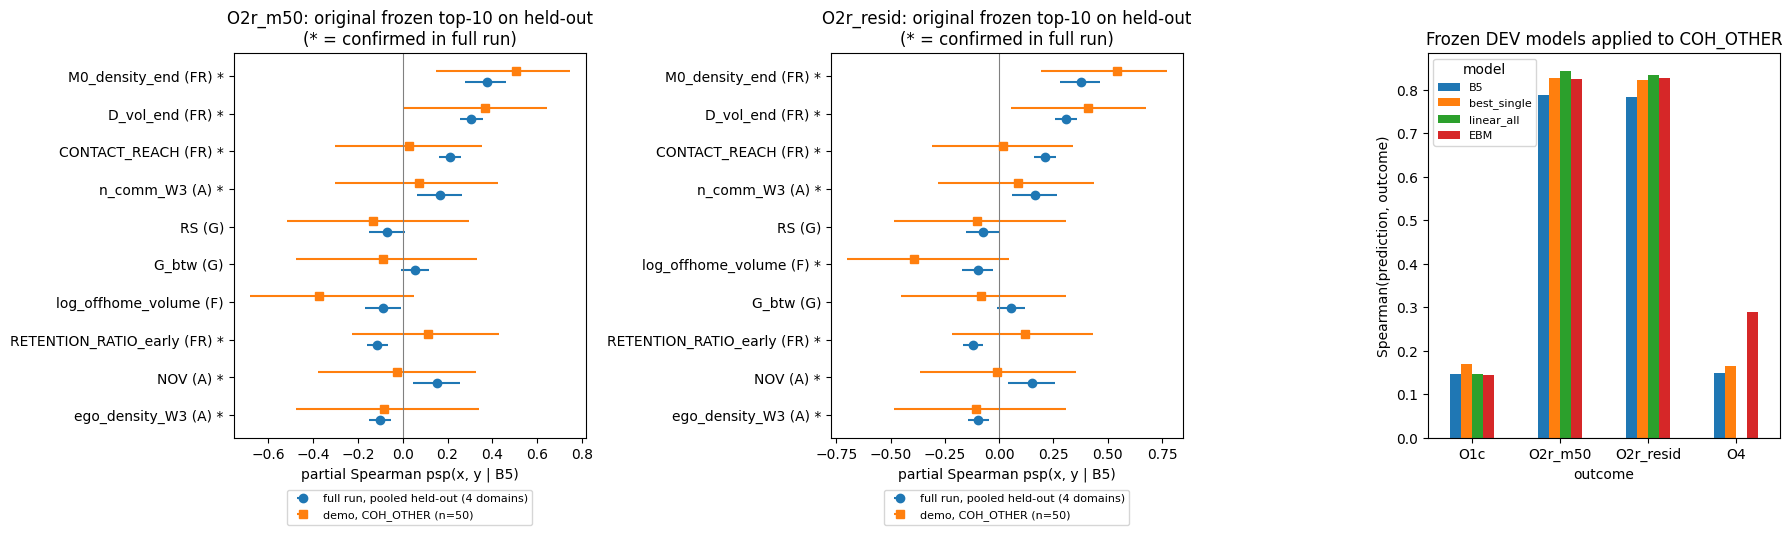

In [14]:
orig_hs = meta["original_heldout_summary"]
cmp_rows = []
for o in CONT_OUTCOMES:
    demo_rows = {r["indicator"]: r for r in summary_orig[o] if r["in_top10"]}
    for r in orig_hs[o]:
        dr = demo_rows.get(r["indicator"], {})
        cmp_rows.append({"outcome": o, "indicator": r["indicator"], "family": r["family"],
                         "frozen_sign": r["frozen_sign"],
                         "demo_psp": dr.get("pooled"), "demo_ci_lo": (dr.get("pooled_ci") or [np.nan])[0],
                         "demo_ci_hi": (dr.get("pooled_ci") or [np.nan, np.nan])[1],
                         "full_pooled_psp": r["pooled"], "full_ci_lo": r["pooled_ci"][0],
                         "full_ci_hi": r["pooled_ci"][1], "full_confirmed": r["confirmed"]})
cmp = pd.DataFrame(cmp_rows)
pd.set_option("display.width", 160)
for o in CONT_OUTCOMES:
    c = cmp[cmp.outcome == o]
    same = (np.sign(c.demo_psp) == np.sign(c.full_pooled_psp)).sum()
    print(f"\n{o}: demo sign matches full-run pooled sign for {same}/{len(c)} frozen indicators; "
          f"full run confirmed {int(c.full_confirmed.sum())}/{len(c)}")
    print(c[["indicator", "family", "frozen_sign", "demo_psp", "full_pooled_psp", "full_confirmed"]]
          .round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, o in zip(axes[:2], ["O2r_m50", "O2r_resid"]):
    c = cmp[cmp.outcome == o].reset_index(drop=True)
    yy = np.arange(len(c))
    ax.errorbar(c.full_pooled_psp, yy + 0.15, xerr=[c.full_pooled_psp - c.full_ci_lo, c.full_ci_hi - c.full_pooled_psp],
                fmt="o", color="#1f77b4", label="full run, pooled held-out (4 domains)")
    ax.errorbar(c.demo_psp, yy - 0.15, xerr=[(c.demo_psp - c.demo_ci_lo).clip(lower=0), (c.demo_ci_hi - c.demo_psp).clip(lower=0)],
                fmt="s", color="#ff7f0e", label=f"demo, {HELD_UNIT} (n={len(d_held)})")
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_yticks(yy)
    ax.set_yticklabels([f"{i} ({f})" + (" *" if cf else "") for i, f, cf in zip(c.indicator, c.family, c.full_confirmed)])
    ax.invert_yaxis()
    ax.set_xlabel("partial Spearman psp(x, y | B5)")
    ax.set_title(f"{o}: original frozen top-10 on held-out\n(* = confirmed in full run)")
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
learned.plot.bar(ax=axes[2], rot=0)
axes[2].axhline(0, color="grey", lw=0.8)
axes[2].set_ylabel("Spearman(prediction, outcome)")
axes[2].set_title(f"Frozen DEV models applied to {HELD_UNIT}")
axes[2].legend(title="model", fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()